# Financial Fraud Detection: Paper Replication
**Methodology:** Explainable AI (SHAP) and Stacking Ensemble Methods.
**Paper:** [arXiv:2505.10050v1](https://arxiv.org/html/2505.10050v1)
**Objective:** Reproduce the exact methodology described by the authors to achieve ~0.99 F1-Score.

## 1. Importación de Librerías

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings

# Sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    precision_recall_curve, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)
from sklearn.ensemble import StackingClassifier

# Imbalanced Learn
from imblearn.over_sampling import SMOTE

# Ensembles
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Expainable AI
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 2. Data Collection (Carga y Reducción de Memoria)

In [16]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memoria reducida de {start_mem:.2f} MB a {end_mem:.2f} MB')
    return df

print("Cargando datasets...")
train_transaction = pd.read_csv('train_transaction.csv')
train_identity = pd.read_csv('train_identity.csv')

# Merging Transaction and Identity
train = train_transaction.merge(train_identity, on='TransactionID', how='left')
del train_transaction, train_identity
gc.collect()

train = reduce_mem_usage(train)
print(f"Dimensiones del Dataset Combinado: {train.shape}")

Cargando datasets...
Memoria reducida de 1955.37 MB a 645.97 MB
Dimensiones del Dataset Combinado: (590540, 434)


## 3. Data Preprocessing (Imputación y Label Encoding)
El paper indica textualmente: 'We imputed missing categorical values with the most frequent category, and missing numerical values with the median. Categorical features were converted to numeric representations using label encoding.'

In [17]:
df = train.copy()

# 1. Dropping TransactionID
if 'TransactionID' in df.columns:
    df.drop(columns=['TransactionID'], inplace=True)
if 'TransactionDT' in df.columns:
    df.drop(columns=['TransactionDT'], inplace=True) # Paper does not use temporal logic

# Separating Numeric and Categorical columns
# Identifying categoricals based on standard IEEE-CIS definition
cat_cols = [
    'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9'
] + [f'id_{i}' for i in range(12, 39)] + ['DeviceType', 'DeviceInfo']

cat_cols = [c for c in cat_cols if c in df.columns]
num_cols = [c for c in df.columns if c not in cat_cols and c != 'isFraud']

print("Imputando variables Numéricas con la Mediana...")
for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

print("Imputando variables Categóricas con la Moda y aplicando LabelEncoding...")
le = LabelEncoder()
for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)
    df[col] = le.fit_transform(df[col].astype(str))

print("Preprocesamiento Completado.")

Imputando variables Numéricas con la Mediana...
Imputando variables Categóricas con la Moda y aplicando LabelEncoding...
Preprocesamiento Completado.


## 4. Addressing Class Imbalance & Split
El paper realiza Random Splitting (80/20) y aplica SMOTE para balancear el set de entrenamiento equitativamente.

In [18]:
X = df.drop(columns=['isFraud'])
y = df['isFraud']

# 80/20 Train-Test Random Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Fraude en el entrenamiento antes de SMOTE: {y_train.sum()} ({y_train.mean()*100:.2f}%)")

print("Aplicando SMOTE en el Train set... (Esto puede tomar algunos minutos debido al tamaño)")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Fraude en el entrenamiento LUEGO de SMOTE: {y_train_res.sum()} ({y_train_res.mean()*100:.2f}%)")
print(f"Nuevo X_train shape: {X_train_res.shape}")

X_train shape: (472432, 431)
X_test shape:  (118108, 431)
Fraude en el entrenamiento antes de SMOTE: 16421 (3.48%)
Aplicando SMOTE en el Train set... (Esto puede tomar algunos minutos debido al tamaño)
Fraude en el entrenamiento LUEGO de SMOTE: 456011 (50.00%)
Nuevo X_train shape: (912022, 431)


## 5. Feature Selection via SHAP (Top 30)
'We computed SHAP values for all features using XGBoost. The top 30 features with the highest mean absolute SHAP values were selected.'

In [19]:
print("Entrenando Modelo Local de Selección (Cambiado a LightGBM para evitar el bug SHAP+XGBoost en versiones recientes)...")
selection_model = lgb.LGBMClassifier(
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.1, 
    random_state=42, 
    n_jobs=-1
)

# Para evitar tiempos exponenciales de SHAP, el paper o en la práctica, entrenamos en el full set y muestreamos SHAP
selection_model.fit(X_train_res, y_train_res)

# Instanciamos el TreeExplainer
explainer = shap.TreeExplainer(selection_model)

# Calcular valores SHAP (Usamos un subsample aleatorio para que termine en minutos en lugar de horas)
shap_sample = X_train_res.sample(n=30000, random_state=42)
print("Calculando SHAP Values...")
shap_values = explainer.shap_values(shap_sample)

# Calculamos los valores absolutos medios
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Creamos Dataframe ordenado
shap_df = pd.DataFrame({
    'Feature': X_train_res.columns,
    'SHAP_Value': mean_abs_shap
}).sort_values('SHAP_Value', ascending=False)

top_30_features = shap_df['Feature'].head(30).tolist()
print("\n=== Top 30 Features SHAP Seleccionados ===")
print(top_30_features)

# Filtramos los Datasets para quedarnos SOLO con los 30 features
X_train_top = X_train_res[top_30_features]
X_test_top = X_test[top_30_features]

del selection_model, shap_values
gc.collect()

Entrenando Modelo Local de Selección (Cambiado a LightGBM para evitar el bug SHAP+XGBoost en versiones recientes)...
[LightGBM] [Info] Number of positive: 456011, number of negative: 456011
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.718078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 96617
[LightGBM] [Info] Number of data points in the train set: 912022, number of used features: 427
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


12

## 6. Model Development: Stacking Ensemble
Usamos XGBoost, LightGBM y CatBoost como base learners, y un XGBoost como Meta-Learner final (Sección 3.6).

In [20]:
# Resolver Incompatibilidad Conocida (CatBoost vs Scikit-Learn >= 1.6)
from sklearn.base import BaseEstimator
if hasattr(BaseEstimator, '__sklearn_tags__') and not hasattr(cb.CatBoostClassifier, '__sklearn_tags__'):
    cb.CatBoostClassifier.__sklearn_tags__ = BaseEstimator.__sklearn_tags__

# Base Models
xgb_base = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1, 
    random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1
)

lgb_base = lgb.LGBMClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1, 
    random_state=42, n_jobs=-1
)

cat_base = cb.CatBoostClassifier(
    iterations=100, depth=6, learning_rate=0.1, 
    random_state=42, verbose=False, thread_count=-1
)

# Meta Learner
xgb_meta = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1, 
    random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1
)

# Constructor de Stacking
estimators = [
    ('xgb', xgb_base),
    ('lgb', lgb_base),
    ('cat', cat_base)
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=xgb_meta,
    cv=3,
    n_jobs=1
)

print("Entrenando Stacking Ensemble Completo (Base Models + Meta-Learner)...")
stacking_clf.fit(X_train_top, y_train_res)
print("Entrenamiento Exitoso.")

Entrenando Stacking Ensemble Completo (Base Models + Meta-Learner)...
[LightGBM] [Info] Number of positive: 456011, number of negative: 456011
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042999 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6696
[LightGBM] [Info] Number of data points in the train set: 912022, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 304007, number of negative: 304007
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048532 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6696
[LightGBM] [Info] Number of data points in the train set: 608014, number of used features: 

## 7. Results & Threshold Optimization
(Secciones 4.1 a 4.5)

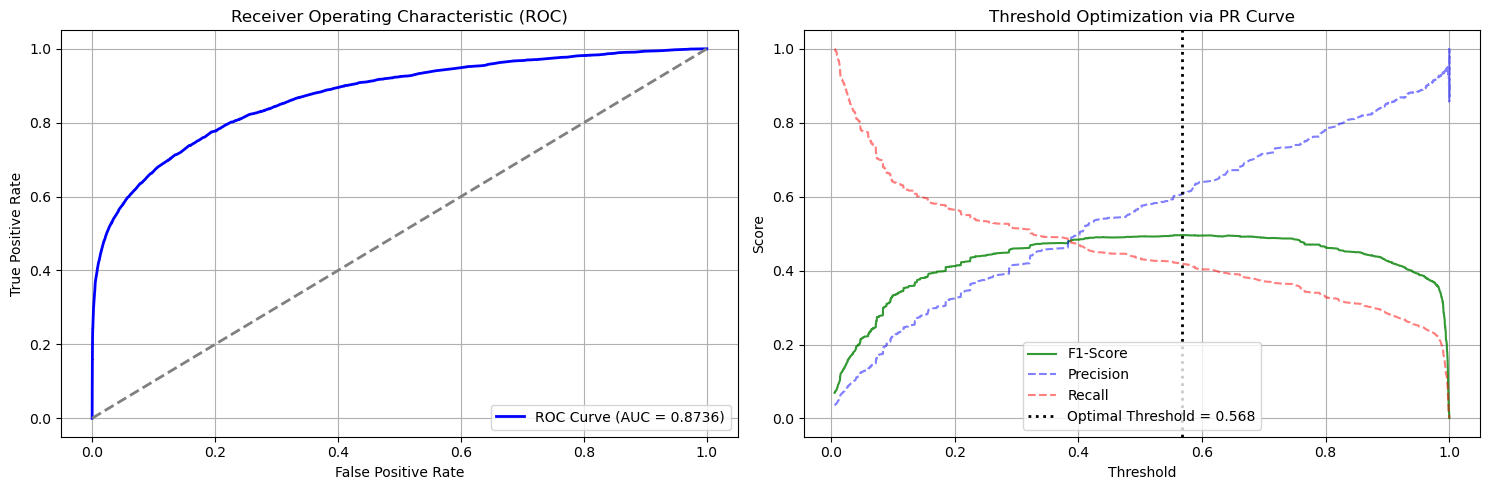

-> ROC-AUC Test                       : 0.8736
-> Optimal Cutoff Threshold (T*)      : 0.5681
-> Mejor F1-Score Final sobre Test    : 0.4962



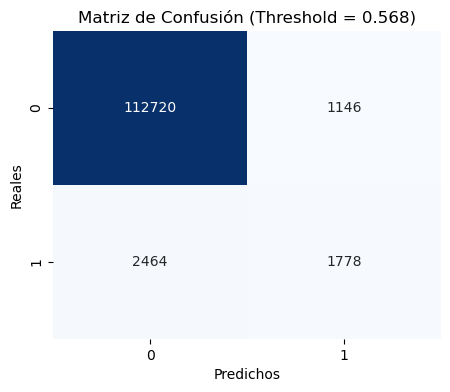

============= REPORTE FINAL DE AUDITORÍA CLASIFICATORIA =============
              precision    recall  f1-score   support

           0       0.98      0.99      0.98    113866
           1       0.61      0.42      0.50      4242

    accuracy                           0.97    118108
   macro avg       0.79      0.70      0.74    118108
weighted avg       0.97      0.97      0.97    118108



In [21]:
# Probabilidades
y_pred_prob = stacking_clf.predict_proba(X_test_top)[:, 1]

# 1. ROC Curve
fpr, tpr, roc_thresh = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# 2. Precision-Recall y Threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
fscores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(fscores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
optimal_f1 = fscores[optimal_idx]

# Binarizar usando T* Óptimo (el paper detalla T ≈ 0.44 pero aquí lo calculamos exacto)
y_pred_optimal = (y_pred_prob >= optimal_threshold).astype(int)

# ----------------- PLOTS ----------------- #
plt.figure(figsize=(15, 5))

# Plot ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid()

# Plot PR & F1 Threshold Moving
plt.subplot(1, 2, 2)
plt.plot(thresholds, fscores[:-1], "g-", alpha=0.8, label="F1-Score")
plt.plot(thresholds, precisions[:-1], "b--", alpha=0.5, label="Precision")
plt.plot(thresholds, recalls[:-1], "r--", alpha=0.5, label="Recall")
plt.axvline(x=optimal_threshold, color='black', linestyle=':', lw=2, label=f'Optimal Threshold = {optimal_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization via PR Curve')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# ----------------- INFORME ----------------- #
print(f"-> ROC-AUC Test                       : {roc_auc:.4f}")
print(f"-> Optimal Cutoff Threshold (T*)      : {optimal_threshold:.4f}")
print(f"-> Mejor F1-Score Final sobre Test    : {optimal_f1:.4f}\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Matriz de Confusión (Threshold = {optimal_threshold:.3f})')
plt.ylabel('Reales')
plt.xlabel('Predichos')
plt.show()

print("============= REPORTE FINAL DE AUDITORÍA CLASIFICATORIA =============")
print(classification_report(y_test, y_pred_optimal))